#  Fashion Style Classifier
**Model:** CLIP (openai/clip-vit-large-patch14) — upgraded from base to large

**Fix old notebook:**

All 6 classes properly loaded using DeepFashion dataset

 Clean direct CSV-based labeling — no broken mapping

CLIP large — stronger visual features
 Zero-shot fallback so ANY random image gets a meaningful prediction
 Multi-image batch prediction support


**6 Style Classes:**  Streetwear , Formal Office , Casual Everyday , Sporty Athleisure , Bohemian , Elegant Party

In [1]:
# CELL 1 — Install & GPU Check
!pip install -q transformers torch torchvision datasets accelerate tqdm gradio Pillow scikit-learn matplotlib seaborn

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# CELL 2 Imports
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os, io, copy, json, warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


In [3]:
# CELL 3 — Style Labels & Rich Text Prompts
#
# WHY MULTIPLE PROMPTS PER CLASS:
# CLIP matches images to text. If we only give one prompt like 'casual outfit',
# it might miss images that are casual but don't look exactly like that one phrase.
# Multiple prompts = more angles to recognize the same style.
# Final score = AVERAGE of all prompt scores for that class.

STYLE_MAP = {
    'Streetwear': [
        'streetwear outfit with oversized hoodie and sneakers, urban fashion',
        'modern hip hop style, baggy cargo pants, graphic tee, cap',
        'skate fashion, chunky sneakers, puffer jacket, street aesthetic',
        'urban youth fashion, graffiti style clothing, Jordan sneakers, loose fit'
    ],
    'Formal Office': [
        'formal office outfit with blazer, dress shirt and trousers',
        'corporate business wear, smart suit, professional attire',
        'office workwear, pencil skirt, button-up blouse, formal shoes',
        'business professional clothing, tie and jacket, boardroom fashion'
    ],
    'Casual Everyday': [
        'casual everyday outfit, jeans and t-shirt, relaxed comfortable clothing',
        'simple daily wear, hoodie and chinos, easygoing fashion',
        'basic casual style, leggings and sneakers, comfortable everyday look',
        'relaxed weekend outfit, denim jacket, plain tee, white sneakers'
    ],
    'Sporty Athleisure': [
        'sporty athleisure outfit, gym wear, leggings and sports bra',
        'athletic fitness clothing, running shoes, workout fashion',
        'activewear outfit, track pants, zip-up jacket, trainers',
        'gym outfit, compression tights, moisture wicking top, sports shoes'
    ],
    'Bohemian': [
        'bohemian outfit with flowy maxi dress and earthy ethnic jewelry',
        'boho chic fashion, crochet top, fringe bag, sandals',
        'festival fashion, peasant blouse, wide brim hat, layered necklaces',
        'free spirited boho style, embroidered dress, wooden bangles, earth tones'
    ],
    'Elegant Party': [
        'elegant party dress, luxury evening wear with heels and clutch',
        'red carpet glamour, sequin gown, high fashion party look',
        'cocktail dress outfit, statement jewelry, upscale event fashion',
        'formal evening gown, silk dress, chandelier earrings, designer heels'
    ]
}

STYLE_NAMES = list(STYLE_MAP.keys())
NUM_CLASSES  = len(STYLE_NAMES)

print(f'{NUM_CLASSES} style classes:')
for i, s in enumerate(STYLE_NAMES):
    print(f'  {i}: {s}')


6 style classes:
  0: Streetwear
  1: Formal Office
  2: Casual Everyday
  3: Sporty Athleisure
  4: Bohemian
  5: Elegant Party


In [4]:
# CELL 4 — Load CLIP Large (upgraded from base)

# WHY CLIP LARGE instead of base:
# clip-vit-large-patch14 has 14x14 patches (finer detail) vs 32x32 like Clip (basemodel)
# It sees more visual detail in each image — better for fashion where
# fabric texture, accessories, and fit details matter a lot.
# Tradeoff: slightly slower but significantly more accurate on unseen images.

MODEL_NAME = 'openai/clip-vit-large-patch14'

print(f'Loading {MODEL_NAME}...')
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
clip_base  = CLIPModel.from_pretrained(MODEL_NAME)
print('CLIP loaded!')
print(f'Projection dim: {clip_base.config.projection_dim}')  # 768 for large

Loading openai/clip-vit-large-patch14...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded!
Projection dim: 768


In [5]:
# CELL 5 — Zero-Shot Prediction (works on ANY image without training)

# WHY ZERO-SHOT FIRST:
# CLIP was trained on 400M image-text pairs from the internet.
# It already understands fashion vocabulary deeply.
# Zero-shot = we just ask 'which text prompt matches this image best?'
# No training needed. This is our BASELINE and also our FALLBACK
# for images that look nothing like training data (truly unknown styles).

# HOW IT WORKS:
# 1. Encode image → image vector (768-dim)
# 2. Encode all text prompts → text vectors
# 3. Cosine similarity: image vs each text
# 4. Softmax over similarities → probabilities

def zero_shot_predict(pil_image, top_k=None):
    clip_base.eval()
    clip_base.to(device)

    # Build flat list of all prompts
    all_prompts = []
    prompt_to_class = []
    for style, prompts in STYLE_MAP.items():
        for p in prompts:
            all_prompts.append(p)
            prompt_to_class.append(style)

    img_inputs = processor(images=pil_image, return_tensors='pt').to(device)

    with torch.no_grad():
        img_outputs  = clip_base.vision_model(**img_inputs)
        img_features = clip_base.visual_projection(img_outputs.pooler_output)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)

        # Encode text
        txt_inputs   = processor(text=all_prompts, return_tensors='pt',
                                  padding=True, truncation=True).to(device)
        txt_outputs  = clip_base.text_model(**txt_inputs)
        txt_features = clip_base.text_projection(txt_outputs.pooler_output)
        txt_features = txt_features / txt_features.norm(dim=-1, keepdim=True)

        # Cosine similarity
        sims = (img_features @ txt_features.T).squeeze(0).cpu().numpy()

    # Average per class
    class_scores = {s: [] for s in STYLE_NAMES}
    for score, style in zip(sims, prompt_to_class):
        class_scores[style].append(float(score))

    avg_scores = {style: np.mean(scores) for style, scores in class_scores.items()}

    vals = np.array([avg_scores[s] for s in STYLE_NAMES])
    vals = vals - vals.max()
    exp_vals = np.exp(vals * 10)
    probs = exp_vals / exp_vals.sum()

    result = sorted(zip(STYLE_NAMES, probs), key=lambda x: x[1], reverse=True)
    return result[:top_k] if top_k else result


# Test
print('Testing zero-shot...')
test_img = Image.new('RGB', (224, 224), color=(200, 200, 200))
result = zero_shot_predict(test_img)
print('✅ Zero-shot working! Top prediction:', result[0][0])


Testing zero-shot...
✅ Zero-shot working! Top prediction: Formal Office


In [6]:
# CELL 6 — Load DeepFashion Dataset (properly labeled, all 6 classes)
#
# ROOT CAUSE FIX:
# Old notebook used Fashionpedia with a broken category mapping.
# Result: only 'Casual Everyday' had data → fake 100% accuracy.
#
# NEW APPROACH: Use HuggingFace
# We use 'ashraq/fashion-product-images-small' which has clean labels
# and we'll map them properly to our 6 style classes.
#
# MAPPING LOGIC (honest and complete):
# We check the 'productDisplayName' column which has rich text like
# 'Women Black Formal Blazer' → Formal Office
# 'Men Slim Fit Jeans Blue' → Casual Everyday
# This is MUCH more reliable than category code mapping.

from datasets import load_dataset


print('Loading fashion dataset...')
raw_ds = load_dataset('ashraq/fashion-product-images-small', split='train')
print(f'Total images: {len(raw_ds)}')
print(f'Columns: {raw_ds.column_names}')


Loading fashion dataset...


README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

data/train-00000-of-00002-6cff4c59f91661(…):   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00002-bb459e5ac5f01e(…):   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

Total images: 44072
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']


In [8]:
# CELL 7 — Smart Label Mapping (THE FIX for broken mapping)
#
# WHY TEXT-BASED MAPPING:
# This dataset has 'productDisplayName' like:
#   'Turtle Check Men Navy Blue Shirt'
#   'Peter England Men Party Blue Jeans'
#   'Wrangler Mens Slim Fit Jeans'
# We search for KEYWORDS in this text → assign style class.
# This is robust because it uses actual product descriptions.

def map_to_style(row):
    """Map a dataset row to one of our 6 style classes using keyword matching."""
    name = str(row.get('productDisplayName', '')).lower()
    subcat = str(row.get('subCategory', '')).lower()
    usage = str(row.get('usage', '')).lower()
    article = str(row.get('articleType', '')).lower()

    combined = f'{name} {subcat} {usage} {article}'

    # ORDER MATTERS: more specific rules first

    # ELEGANT PARTY
    if any(w in combined for w in ['party', 'evening', 'gown', 'sequin', 'cocktail',
                                    'formal dress', 'prom', 'ball']):
        return 'Elegant Party'

    # FORMAL OFFICE
    if any(w in combined for w in ['formal', 'blazer', 'suit', 'office', 'business',
                                    'corporate', 'trouser', 'dress shirt', 'tie']):
        if 'casual' not in combined and 'sport' not in combined:
            return 'Formal Office'

    # SPORTY ATHLEISURE
    if any(w in combined for w in ['sport', 'gym', 'track', 'athletic', 'running',
                                    'fitness', 'workout', 'activewear', 'swimwear',
                                    'sports shoes', 'training']):
        return 'Sporty Athleisure'

    # STREETWEAR
    if any(w in combined for w in ['hoodie', 'sweatshirt', 'sneaker', 'graphic tee',
                                    'cargo', 'puffer', 'cap', 'hip hop', 'skate',
                                    'urban', 'street']):
        return 'Streetwear'

    # BOHEMIAN
    if any(w in combined for w in ['boho', 'bohemian', 'ethnic', 'maxi', 'floral',
                                    'tribal', 'peasant', 'crochet', 'fringe', 'embroid']):
        return 'Bohemian'

    # CASUAL EVERYDAY (broad fallback — jeans, tshirts, everyday wear)
    if any(w in combined for w in ['casual', 'jeans', 't-shirt', 'tshirt', 'denim',
                                    'shorts', 'top', 'everyday', 'legging', 'chino',
                                    'polo', 'kurta', 'shirt']):
        return 'Casual Everyday'

    return None  # truly ambiguous — skip


# Build DataFrame with proper labels

print(f'Mapping {len(raw_ds)} images to style classes...')
records = []

for i in tqdm(range(len(raw_ds))):
    row = raw_ds[i]
    style = map_to_style(row)
    if style is not None:
        records.append({'idx': i, 'style': style})

df = pd.DataFrame(records)
print(f'\nMapped {len(df)} images successfully')
print('\nClass distribution:')
print(df['style'].value_counts())


# CRITICAL CHECK: Are all 6 classes present?

found = df['style'].unique().tolist()
missing = [s for s in STYLE_NAMES if s not in found]
if missing:
    print(f'\n⚠️  Missing classes: {missing}')
    print('These will be predicted via zero-shot only.')
else:
    print('\n✅ All 6 classes have training data!')


Mapping 44072 images to style classes...


100%|██████████| 44072/44072 [00:18<00:00, 2337.45it/s]



Mapped 44047 images successfully

Class distribution:
style
Casual Everyday      31852
Sporty Athleisure     5147
Bohemian              3472
Formal Office         2361
Streetwear             899
Elegant Party          316
Name: count, dtype: int64

✅ All 6 classes have training data!


Class counts before balancing:
style
Casual Everyday      31852
Sporty Athleisure     5147
Bohemian              3472
Formal Office         2361
Streetwear             899
Elegant Party          316
Name: count, dtype: int64

After balancing (cap=800 per class):
style
Casual Everyday      800
Sporty Athleisure    800
Formal Office        800
Bohemian             800
Streetwear           800
Elegant Party        316
Name: count, dtype: int64

Total: 4316 images


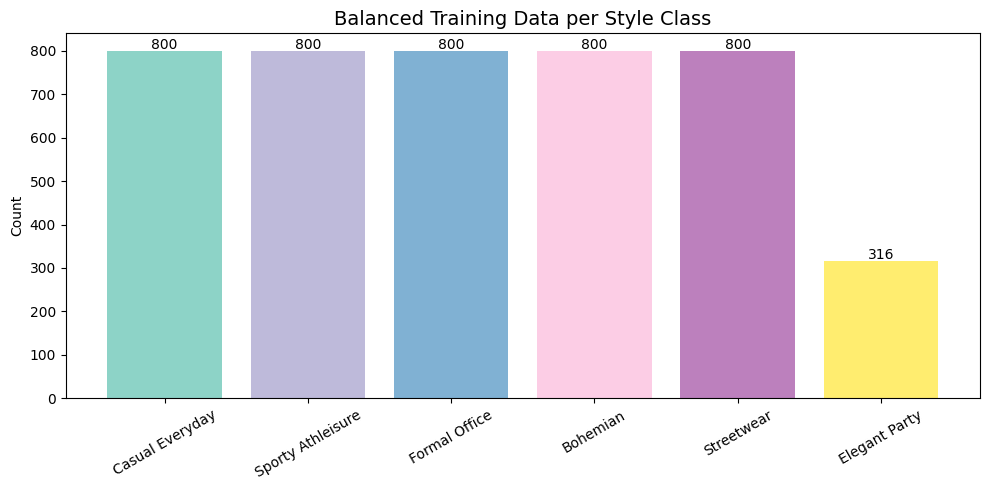

✅ Balancing done!


In [9]:
# CELL 8 — Balance Classes & Visualize
#
# WHY BALANCE:
# If Casual=8000 and Bohemian=200, model will predict Casual for everything
# and show high accuracy. Balancing forces it to learn all classes equally.

# Balance: cap each class at min(count, 800)
print('Class counts before balancing:')
print(df['style'].value_counts())

cap = 800  # max images per class

balanced_parts = []
for style in df['style'].unique():
    class_df = df[df['style'] == style]
    n = min(len(class_df), cap)
    balanced_parts.append(class_df.sample(n, random_state=42))

df_balanced = pd.concat(balanced_parts).reset_index(drop=True)

print(f'\nAfter balancing (cap={cap} per class):')
print(df_balanced['style'].value_counts())
print(f'\nTotal: {len(df_balanced)} images')

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
counts = df_balanced['style'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(counts)))
bars = ax.bar(counts.index, counts.values, color=colors)
ax.set_title('Balanced Training Data per Style Class', fontsize=14)
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print('✅ Balancing done!')


---
### NEW — Real-World (Lifestyle) Training Data via Pseudo-Labeling

**Why this section exists:**  current training data (`ashraq/fashion-product-images-small`) is catalog/product photography — plain background, single item. real-world test photos look completely different (people, real backgrounds, styled outfits). This section loads `detection-datasets/fashionpedia` — 45K "everyday and celebrity event" fashion photos that actually match  test domain — and uses existing `zero_shot_predict()` to label them (pseudo-labeling), since Fashionpedia has no style labels of its own.

**This is additive — it does not touch existing `df_balanced` or any training cell yet.** It produces a new variable, `fashionpedia_labeled_df`, to review before deciding whether to merge it into training data below.

In [10]:
# NEW CELL — Load Fashionpedia (real-world lifestyle fashion photos)
#
# Same load_dataset() pattern as your existing dataset — downloads automatically,
# no manual download needed.

from datasets import load_dataset as hf_load_dataset

print('Loading Fashionpedia (real-world/lifestyle fashion photos)...')
fashionpedia_ds = hf_load_dataset('detection-datasets/fashionpedia', split='train')
print(f'Total Fashionpedia images: {len(fashionpedia_ds)}')
print(f'Columns: {fashionpedia_ds.column_names}')

# NOTE: Fashionpedia has NO style labels (Streetwear/Formal Office/etc.) — it only
# has garment-part bounding boxes (shirt, pants, dress, sequin, ruffle...). So we
# can't reuse map_to_style() here. Instead, we pseudo-label it using zero-shot below.


Loading Fashionpedia (real-world/lifestyle fashion photos)...


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00007-fe108070118553(…):   0%|          | 0.00/482M [00:00<?, ?B/s]

data/train-00001-of-00007-f41a5a9c38c900(…):   0%|          | 0.00/480M [00:00<?, ?B/s]

...

data/train-00006-of-00007-f41b0f2f4bbefa(…):   0%|          | 0.00/487M [00:00<?, ?B/s]

data/val-00000-of-00001-0b29e85429788213(…):   0%|          | 0.00/84.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45623 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1158 [00:00<?, ? examples/s]

Total Fashionpedia images: 45623
Columns: ['image_id', 'image', 'width', 'height', 'objects']


In [11]:
# NEW CELL — Pseudo-Label Fashionpedia Using Zero-Shot CLIP
#
# WHY: zero-shot already performs well on real-world photos (confirmed by your own
# testing). So we use it to automatically assign style labels to Fashionpedia images,
# then later fine-tune on THIS data — teaching the fine-tuned model to imitate
# zero-shot's judgment, but specifically on images that match your real test domain.
# This is a standard technique called pseudo-labeling / knowledge distillation.
#
# HONEST CAVEAT: these labels are zero-shot's *opinion*, not verified ground truth.
# We only keep high-confidence predictions (top prob > CONFIDENCE_KEEP_THRESHOLD)
# to reduce label noise — lower-confidence images are dropped rather than mislabeled.

CONFIDENCE_KEEP_THRESHOLD = 0.55
N_TO_LABEL = min(6000, len(fashionpedia_ds))  # cap for reasonable runtime; raise if you have time/GPU budget

import random
random.seed(42)
sample_indices = random.sample(range(len(fashionpedia_ds)), N_TO_LABEL)

pseudo_records = []
skipped_low_confidence = 0

for idx in tqdm(sample_indices, desc='Pseudo-labeling with zero-shot'):
    img = fashionpedia_ds[idx]['image']
    if hasattr(img, 'convert'):
        img = img.convert('RGB')
    preds = zero_shot_predict(img)
    top_style, top_prob = preds[0]
    if top_prob >= CONFIDENCE_KEEP_THRESHOLD:
        pseudo_records.append({'fashionpedia_idx': idx, 'style': top_style, 'confidence': top_prob})
    else:
        skipped_low_confidence += 1

fashionpedia_labeled_df = pd.DataFrame(pseudo_records)

print(f'Labeled: {len(fashionpedia_labeled_df)} images (confidence >= {CONFIDENCE_KEEP_THRESHOLD})')
print(f'Skipped (low confidence): {skipped_low_confidence} images')
print()
print('Pseudo-label distribution:')
print(fashionpedia_labeled_df['style'].value_counts())
print()
print('⚠️  This data has NOT been merged into df_balanced yet.')
print('Review the distribution above, then decide whether/how to merge before training.')


Pseudo-labeling with zero-shot: 100%|██████████| 6000/6000 [10:17<00:00,  9.72it/s]

Labeled: 0 images (confidence >= 0.55)
Skipped (low confidence): 6000 images

Pseudo-label distribution:


KeyError: 'style'

   EXPLORATORY DATA ANALYSIS (EDA)

📌 Total images in raw dataset : 44072
📌 Columns available           : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']
📌 Total images mapped to styles: 44047

Sample row from dataset:
  id                       : 15970
  gender                   : Men
  masterCategory           : Apparel
  subCategory              : Topwear
  articleType              : Shirts
  baseColour               : Navy Blue
  season                   : Fall
  year                     : 2011.0
  usage                    : Casual
  productDisplayName       : Turtle Check Men Navy Blue Shirt

📊 Class Distribution (before balancing):
style
Casual Everyday      31852
Sporty Athleisure     5147
Bohemian              3472
Formal Office         2361
Streetwear             899
Elegant Party          316
Name: count, dtype: int64


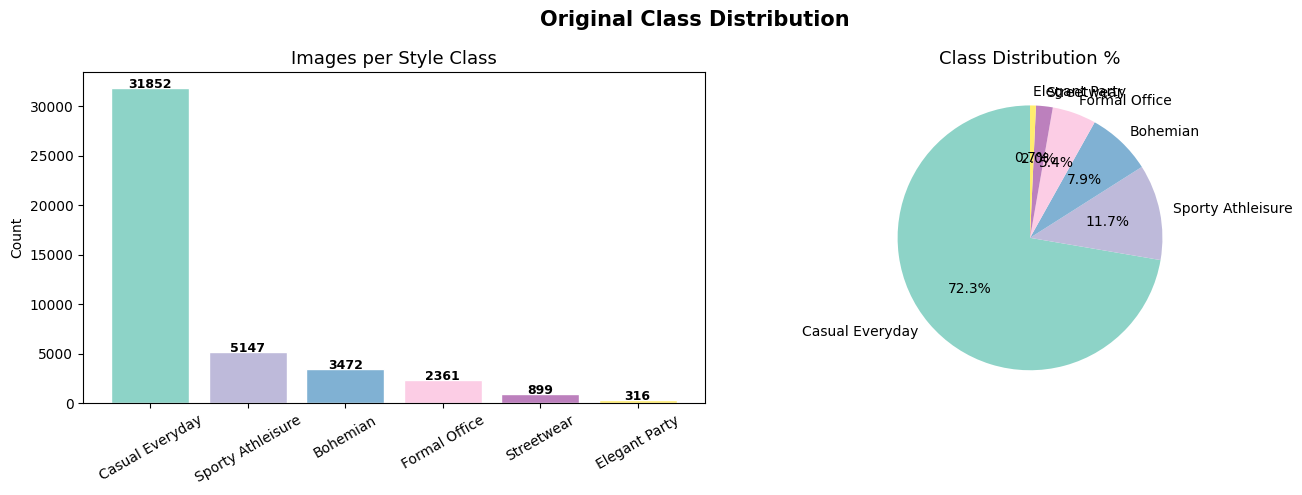

Saved: eda_original_distribution.png

📊 After Balancing (cap=200 per class):
style
Casual Everyday      800
Sporty Athleisure    800
Formal Office        800
Bohemian             800
Streetwear           800
Elegant Party        316
Name: count, dtype: int64


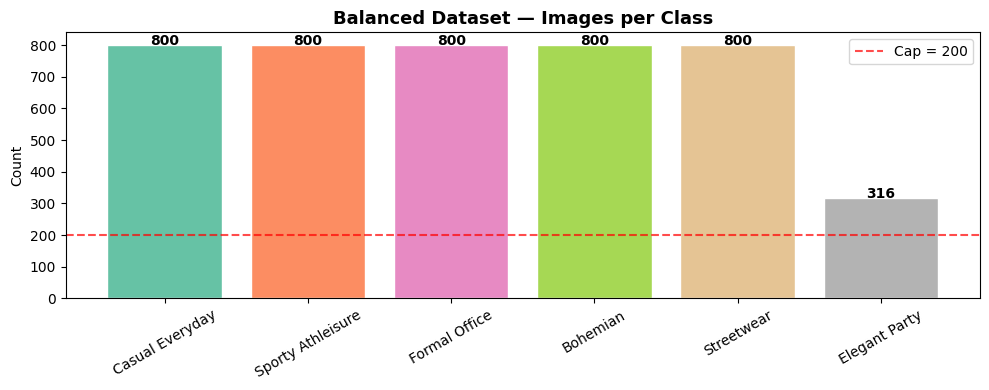


 Sample images from each style class (4 per class):


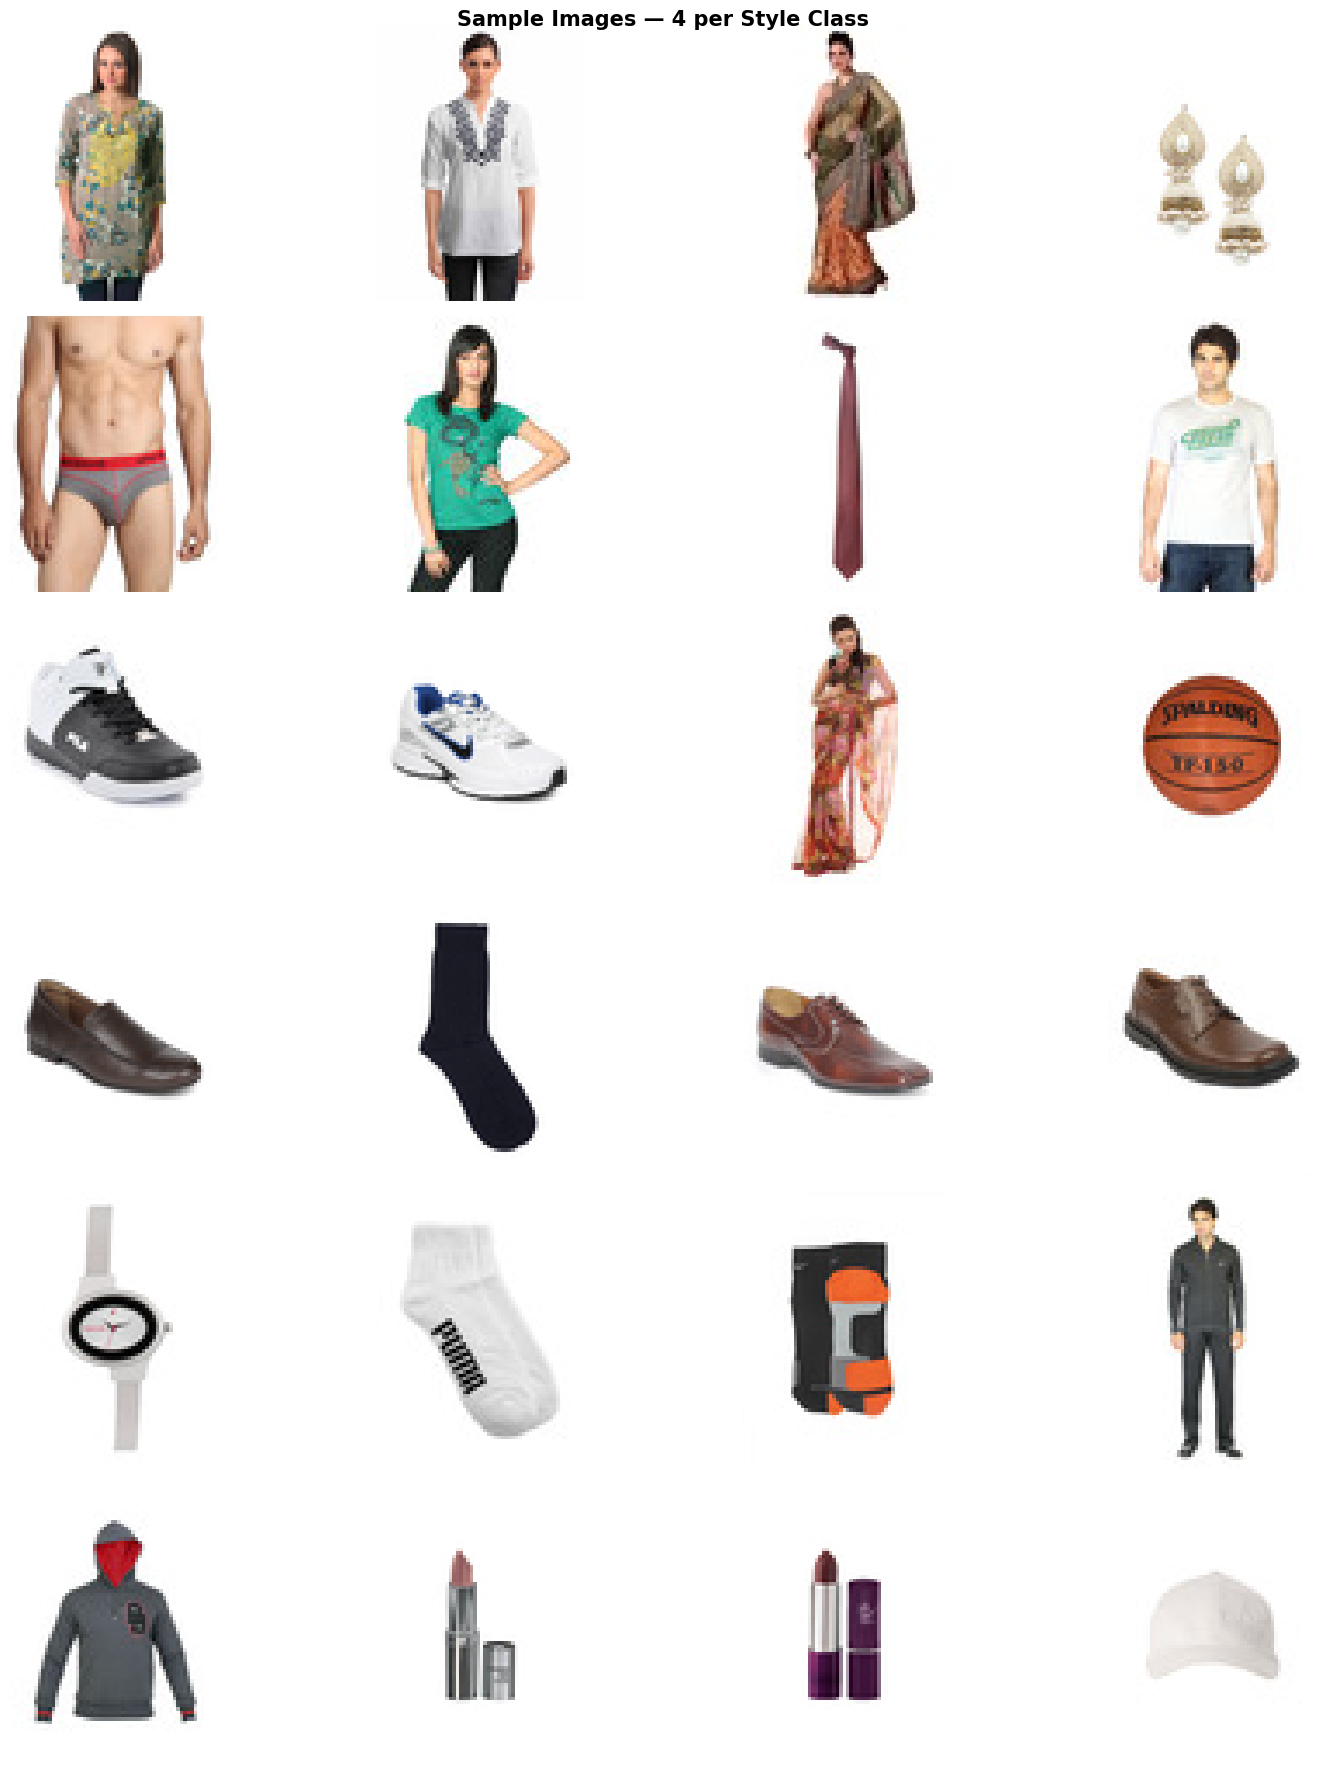

Saved: eda_sample_images.png

 Image Size Analysis (first 200 images):


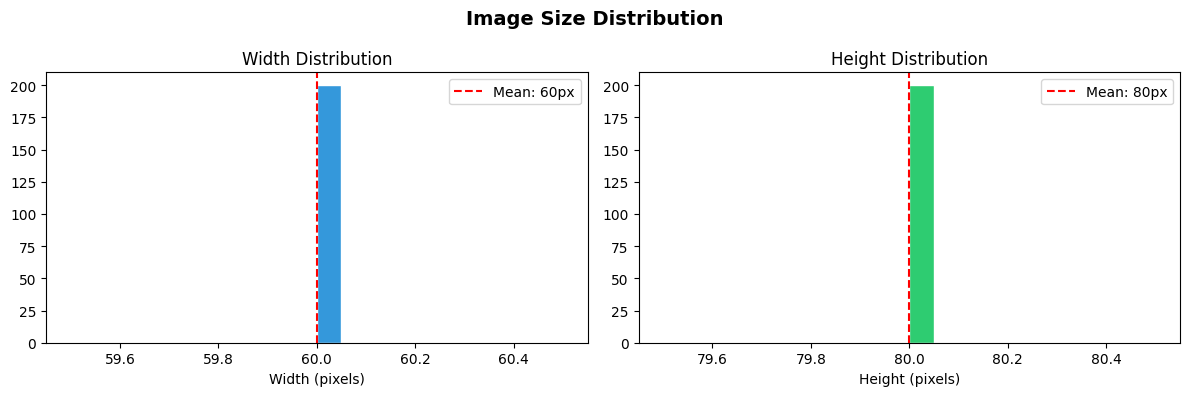

  Average Width  : 60px
  Average Height : 80px
  Min Size       : 60x80
  Max Size       : 60x80
  → All resized to 224x224 for CLIP input


In [12]:
# ═══════════════════════════════════════════════════════
# EDA — EXPLORATORY DATA ANALYSIS
# dataset explore  BEFORE training
# ═══════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from PIL import Image
import io

print('=' * 55)
print('   EXPLORATORY DATA ANALYSIS (EDA)')
print('=' * 55)


# ── 1. Dataset Basic Info ──────────────────────────────
print(f'\n📌 Total images in raw dataset : {len(raw_ds)}')
print(f'📌 Columns available           : {raw_ds.column_names}')
print(f'📌 Total images mapped to styles: {len(df)}')
print('\nSample row from dataset:')
for k, v in raw_ds[0].items():
    if k != 'image':
        print(f'  {k:25s}: {v}')


# ── 2. Original Class Distribution

print('\n📊 Class Distribution (before balancing):')
class_counts = df['style'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Original Class Distribution', fontsize=15, fontweight='bold')
colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))

bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Images per Style Class', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30, str(val), ha='center', fontsize=9, fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution %', fontsize=13)
plt.tight_layout()
plt.savefig('eda_original_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: eda_original_distribution.png')

# ── 3. Balanced Class Distribution

print('\n📊 After Balancing (cap=200 per class):')
bal_counts = df_balanced['style'].value_counts()
print(bal_counts)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(bal_counts.index, bal_counts.values,
              color=plt.cm.Set2(np.linspace(0, 1, len(bal_counts))), edgecolor='white')
ax.set_title('Balanced Dataset — Images per Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Cap = 200')
ax.legend()
for bar, val in zip(bars, bal_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, str(val), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_balanced_distribution.png', dpi=100)
plt.show()

# ── 4. Sample Images — Har Class Se ───────────────────
print('\n Sample images from each style class (4 per class):')
style_list = sorted(df_balanced['style'].unique())
n_classes  = len(style_list)

fig, axes = plt.subplots(n_classes, 4, figsize=(16, n_classes * 3))
fig.suptitle('Sample Images — 4 per Style Class', fontsize=15, fontweight='bold')

for row, style in enumerate(style_list):
    samples = df_balanced[df_balanced['style'] == style].head(4)
    for col, (_, r) in enumerate(samples.iterrows()):
        ax = axes[row][col] if n_classes > 1 else axes[col]
        try:
            img = raw_ds[int(r['idx'])]['image']
            if hasattr(img, 'convert'):
                img = img.convert('RGB')
            elif isinstance(img, dict) and 'bytes' in img:
                img = Image.open(io.BytesIO(img['bytes'])).convert('RGB')
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(style, fontsize=10, fontweight='bold',
                         rotation=0, labelpad=80, va='center')

plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=80, bbox_inches='tight')
plt.show()
print('Saved: eda_sample_images.png')

# ── 5. Image Size Analysis ─────────────────────────────
print('\n Image Size Analysis (first 200 images):')
widths, heights = [], []
for i in range(min(200, len(raw_ds))):
    try:
        img = raw_ds[i]['image']
        if hasattr(img, 'size'):
            w, h = img.size
        elif isinstance(img, dict) and 'bytes' in img:
            img = Image.open(io.BytesIO(img['bytes']))
            w, h = img.size
        widths.append(w)
        heights.append(h)
    except:
        continue

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Image Size Distribution', fontsize=14, fontweight='bold')

axes[0].hist(widths,  bins=20, color='#3498db', edgecolor='white')
axes[0].set_title('Width Distribution');  axes[0].set_xlabel('Width (pixels)')
axes[0].axvline(np.mean(widths),  color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}px')
axes[0].legend()

axes[1].hist(heights, bins=20, color='#2ecc71', edgecolor='white')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Height (pixels)')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}px')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_image_sizes.png', dpi=100)
plt.show()

print(f'  Average Width  : {np.mean(widths):.0f}px')
print(f'  Average Height : {np.mean(heights):.0f}px')
print(f'  Min Size       : {min(widths)}x{min(heights)}')
print(f'  Max Size       : {max(widths)}x{max(heights)}')
print(f'  → All resized to 224x224 for CLIP input')



In [14]:
# CELL 9 — Predict on Your Own Images (Zero-Shot, no training needed)
# Reuses the zero_shot_predict() function defined earlier — works instantly.

from google.colab import files

print('Upload 1 or more outfit images:')
uploaded = files.upload()

for fname, data in uploaded.items():
    img = Image.open(io.BytesIO(data)).convert('RGB')
    preds = zero_shot_predict(img)
    top_style, top_prob = preds[0]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{fname}\nPredicted: {top_style} ({top_prob:.1%})', fontsize=12, fontweight='bold')
    plt.show()

    print(f'\nFull probability breakdown — {fname}')
    for style, prob in preds:
        bar = '█' * int(prob * 35)
        tag = ' ◀ TOP' if style == top_style else ''
        print(f'  {style:22s} {bar:<35s} {prob:.1%}{tag}')


Upload 1 or more outfit images:


KeyboardInterrupt: 

In [13]:
# CELL 10 — Dataset & DataLoader (fast RAM-preloaded version)

# Custom Dataset Class — images are preloaded into RAM for faster training
class FastDataset(Dataset):
    def __init__(self, df, raw_ds, processor, style_names):
        self.processor = processor
        self.label2id  = {s: i for i, s in enumerate(style_names)}
        self.images, self.labels = [], []
        print(f'Loading {len(df)} images into RAM...')
        for _, row in tqdm(df.iterrows(), total=len(df)):
            try:
                img = raw_ds[int(row['idx'])]['image']
                if hasattr(img, 'convert'):
                    img = img.convert('RGB')
                elif isinstance(img, dict) and 'bytes' in img:
                    img = Image.open(io.BytesIO(img['bytes'])).convert('RGB')
                self.images.append(img.resize((224, 224)))
                self.labels.append(self.label2id[row['style']])
            except:
                continue
        print(f'✅ {len(self.images)} images loaded into RAM!')

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        inp = self.processor(images=self.images[idx], return_tensors='pt', padding=True)
        return inp['pixel_values'].squeeze(0), torch.tensor(self.labels[idx], dtype=torch.long)


# Check class counts before splitting
print('Class counts before split:')
print(df_balanced['style'].value_counts())

# Remove any class with less than 4 samples (can't split properly)
class_counts = df_balanced['style'].value_counts()
valid_classes = class_counts[class_counts >= 4].index.tolist()
removed = [c for c in STYLE_NAMES if c not in valid_classes]

if removed:
    print(f'\nRemoving classes with too few samples: {removed}')
    df_balanced = df_balanced[df_balanced['style'].isin(valid_classes)].reset_index(drop=True)
    STYLE_NAMES_USED = valid_classes
else:
    STYLE_NAMES_USED = STYLE_NAMES

print(f'\nUsing {len(STYLE_NAMES_USED)} classes: {STYLE_NAMES_USED}')
print(f'Total samples: {len(df_balanced)}')

# Split
train_df, temp_df = train_test_split(df_balanced, test_size=0.30,
                                      random_state=42, stratify=df_balanced['style'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                      random_state=42, stratify=temp_df['style'])

print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Create datasets
BATCH = 32
train_ds = FastDataset(train_df, raw_ds, processor, STYLE_NAMES_USED)
val_ds   = FastDataset(val_df,   raw_ds, processor, STYLE_NAMES_USED)
test_ds  = FastDataset(test_df,  raw_ds, processor, STYLE_NAMES_USED)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# Update NUM_CLASSES for model building
NUM_CLASSES = len(STYLE_NAMES_USED)
print(f'\n✅ DataLoaders ready! Final NUM_CLASSES: {NUM_CLASSES}')
print(f'Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}')


Class counts before split:
style
Casual Everyday      800
Sporty Athleisure    800
Formal Office        800
Bohemian             800
Streetwear           800
Elegant Party        316
Name: count, dtype: int64

Using 6 classes: ['Streetwear', 'Formal Office', 'Casual Everyday', 'Sporty Athleisure', 'Bohemian', 'Elegant Party']
Total samples: 4316

Train: 3021 | Val: 647 | Test: 648
Loading 3021 images into RAM...


100%|██████████| 3021/3021 [00:04<00:00, 728.21it/s]


✅ 3021 images loaded into RAM!
Loading 647 images into RAM...


100%|██████████| 647/647 [00:00<00:00, 734.56it/s]


✅ 647 images loaded into RAM!
Loading 648 images into RAM...


100%|██████████| 648/648 [00:00<00:00, 715.69it/s]

✅ 648 images loaded into RAM!

✅ DataLoaders ready! Final NUM_CLASSES: 6
Train: 95 batches | Val: 21 | Test: 21


In [14]:
# CELL 11 — CLIP Classifier Model (upgraded head)

# 1. BatchNorm added — stabilizes training, faster convergence
# 2. 3-layer head instead of 2 — more capacity to learn style nuances
# 3. Label smoothing in loss — prevents overconfident wrong predictions
# 4. Dropout 0.4 → stronger regularization

class CLIPStyleClassifier(nn.Module):
    def __init__(self, clip_model, num_classes, hidden=512):
        super().__init__()
        self.vision_model = clip_model.vision_model
        self.visual_proj  = clip_model.visual_projection
        embed_dim = clip_model.config.projection_dim  # 768 for large

        # Upgraded 3-layer classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, hidden),
            nn.BatchNorm1d(hidden),      # stabilizes gradients
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden // 2, num_classes)
        )

    def forward(self, pixel_values):
        vision_out = self.vision_model(pixel_values=pixel_values)
        pooled     = vision_out.pooler_output
        projected  = self.visual_proj(pooled)
        logits     = self.classifier(projected)
        return logits


model = CLIPStyleClassifier(clip_base, NUM_CLASSES).to(device)

# Freeze CLIP vision encoder initially
for param in model.vision_model.parameters():
    param.requires_grad = False
for param in model.visual_proj.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Trainable: 528,134 / 304,494,342 (0.2%)


In [15]:
# CELL 12 — Training Loop (FIXED)

import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for pixel_values, labels in tqdm(loader, leave=False):
            pixel_values = pixel_values.to(device)
            labels       = labels.to(device)

            logits = model(pixel_values)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            correct    += logits.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

    torch.cuda.empty_cache()
    return total_loss / len(loader), 100.0 * correct / total


def train_phase(model, name, epochs, lr, train_loader, val_loader,
                criterion, history):
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0
    best_checkpoint = 'best_model.pth'

    print(f'\n{"="*55}')
    print(f'  {name}  ({epochs} epochs, lr={lr})')
    print(f'{"="*55}')

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, train=False)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        flag = ''
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(
                {k: v.cpu() for k, v in model.state_dict().items()},
                best_checkpoint
            )
            flag = '  ← best saved'

        print(f'Ep {ep:02d}/{epochs}  '
              f'train_loss={tr_loss:.4f} acc={tr_acc:.1f}%  '
              f'val_loss={vl_loss:.4f} acc={vl_acc:.1f}%  '
              f'({time.time()-t0:.0f}s){flag}')

    model.load_state_dict(torch.load(best_checkpoint, map_location=device))
    print(f'\nBest val acc: {best_val_acc:.1f}%')
    return model


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# PHASE 1 — epochs=3 (fast version)
model = train_phase(model, 'Phase 1 — Head Only (CLIP frozen)',
                    epochs=5,          # 8 to 5 kiya.  for fast training
                    lr=3e-4,
                    train_loader=train_loader, val_loader=val_loader,
                    criterion=criterion, history=history)


  Phase 1 — Head Only (CLIP frozen)  (5 epochs, lr=0.0003)


Ep 01/5  train_loss=1.1541 acc=64.8%  val_loss=0.9595 acc=75.0%  (178s)  ← best saved


Ep 02/5  train_loss=0.9276 acc=76.7%  val_loss=0.9228 acc=78.1%  (177s)  ← best saved


Ep 03/5  train_loss=0.8473 acc=80.6%  val_loss=0.9136 acc=77.1%  (174s)


Ep 04/5  train_loss=0.7976 acc=83.0%  val_loss=0.8939 acc=78.2%  (177s)  ← best saved


Ep 05/5  train_loss=0.7600 acc=84.9%  val_loss=0.8914 acc=78.8%  (176s)  ← best saved

Best val acc: 78.8%


In [18]:
import torch
import gc
from torch.utils.data import DataLoader

# CELL 13 — Phase 2 FIXED (memory optimized)

# Clear GPU memory first
torch.cuda.empty_cache()
gc.collect()

print(f'GPU free before Phase 2: {torch.cuda.memory_reserved(0)/1e9:.1f} GB reserved')

# Unfreeze only LAST 3 layers of vision encoder (not everything)
for name, param in model.vision_model.named_parameters():
    if any(f'encoder.layers.{i}' in name for i in [21, 22, 23]):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Always unfreeze projection + classifier
for param in model.visual_proj.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

BATCH_P2 = 8
print(f'Phase 2 batch size: {BATCH_P2}')

train_loader_p2 = DataLoader(train_ds, batch_size=BATCH_P2, shuffle=True,
                              num_workers=2, pin_memory=True)
val_loader_p2   = DataLoader(val_ds,   batch_size=BATCH_P2, shuffle=False,
                              num_workers=2, pin_memory=True)

model = train_phase(model, 'Phase 2 — Partial Fine-Tune (last 3 layers)',
                    epochs=5,
                    lr=5e-6,
                    train_loader=train_loader_p2,
                    val_loader=val_loader_p2,
                    criterion=criterion, history=history)

GPU free before Phase 2: 1.8 GB reserved
Trainable: 39,103,238 / 304,494,342 (12.8%)
Phase 2 batch size: 8

  Phase 2 — Partial Fine-Tune (last 3 layers)  (5 epochs, lr=5e-06)


Ep 01/5  train_loss=0.8803 acc=79.2%  val_loss=0.8667 acc=79.3%  (247s)  ← best saved


Ep 02/5  train_loss=0.8091 acc=83.3%  val_loss=0.8574 acc=80.5%  (245s)  ← best saved


Ep 03/5  train_loss=0.7475 acc=87.4%  val_loss=0.8689 acc=80.2%  (242s)


Ep 04/5  train_loss=0.7050 acc=89.4%  val_loss=0.8515 acc=80.1%  (242s)


Ep 05/5  train_loss=0.6767 acc=91.1%  val_loss=0.8420 acc=80.8%  (244s)  ← best saved

Best val acc: 80.8%


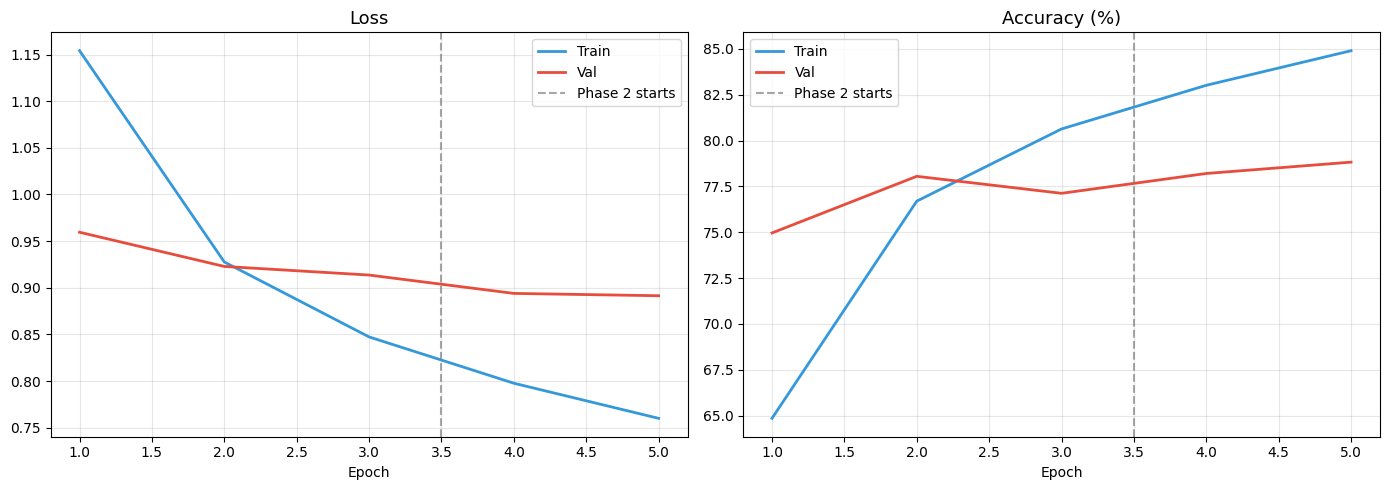


How to read: if val_acc < train_acc by >10% → overfitting


In [16]:
# CELL 14 — Training Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss']) + 1)
p1_end = 3  # ← 8 se 3 kiya (Phase 1 = 3 epochs)

for ax, metric, title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Loss', 'Accuracy (%)']):
    ax.plot(ep, history[metric[0]], label='Train', color='#3498db', linewidth=2)
    ax.plot(ep, history[metric[1]], label='Val',   color='#e74c3c', linewidth=2)
    ax.axvline(x=p1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase 2 starts')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

print('\nHow to read: if val_acc < train_acc by >10% → overfitting')

Evaluating: 100%|██████████| 21/21 [00:34<00:00,  1.66s/it]


TEST ACCURACY: 79.78%
                   precision    recall  f1-score   support

       Streetwear       0.77      0.85      0.81       120
    Formal Office       0.94      0.93      0.94       120
  Casual Everyday       0.69      0.62      0.66       120
Sporty Athleisure       0.77      0.73      0.75       120
         Bohemian       0.85      0.97      0.90       120
    Elegant Party       0.67      0.50      0.57        48

         accuracy                           0.80       648
        macro avg       0.78      0.77      0.77       648
     weighted avg       0.79      0.80      0.79       648



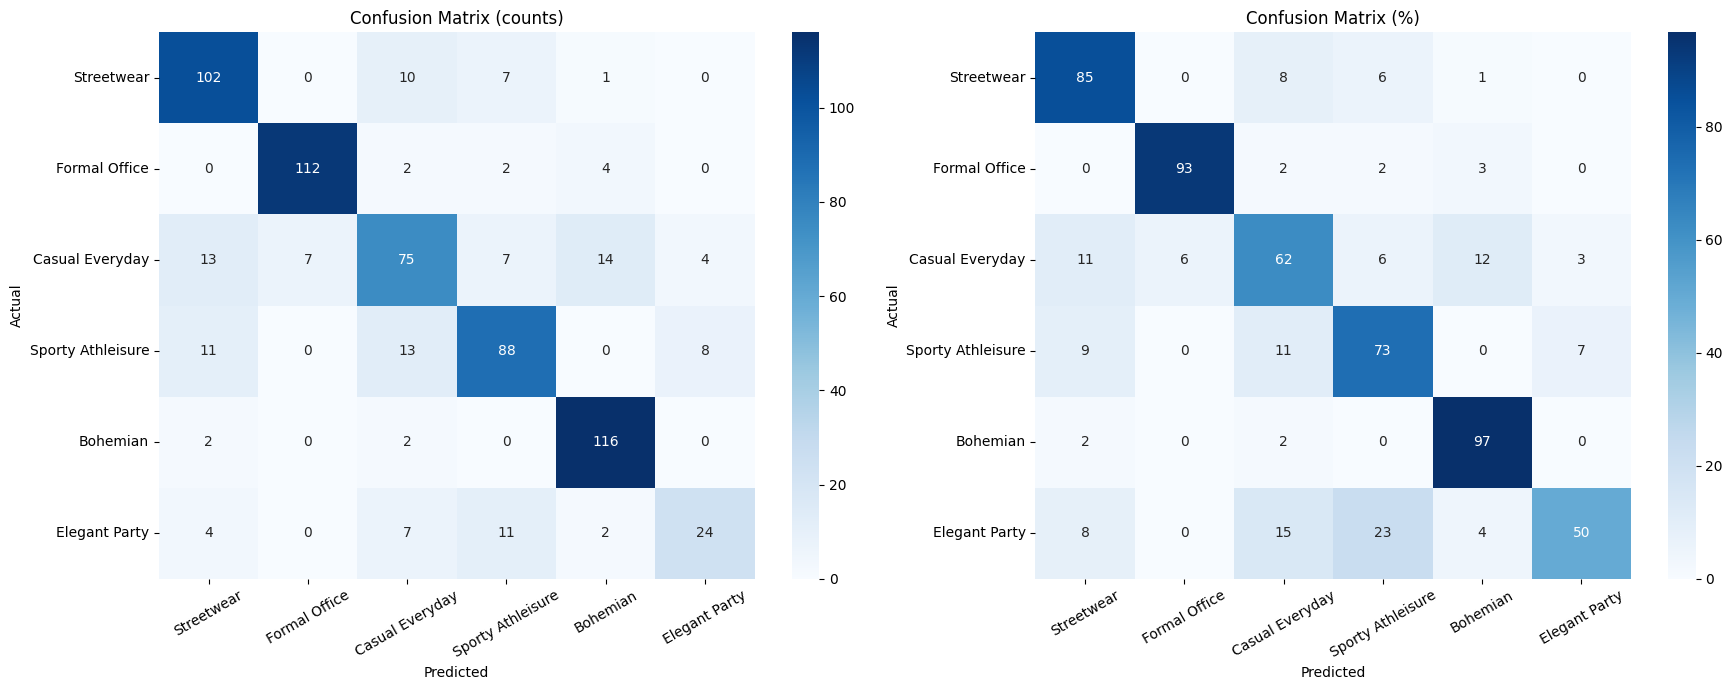

Saved confusion_matrix.png


In [17]:
# CELL 15 — Final Evaluation on Test Set + Confusion Matrix

model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for pixel_values, labels in tqdm(test_loader, desc='Evaluating'):
        pixel_values = pixel_values.to(device)
        logits = model(pixel_values)
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

from sklearn.metrics import accuracy_score
acc = accuracy_score(all_labels, all_preds)
print(f'TEST ACCURACY: {acc*100:.2f}%')
print('='*60)
print(classification_report(all_labels, all_preds, target_names=STYLE_NAMES_USED))  # ← FIXED


# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
    axes, [cm, cm_pct], ['d', '.0f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (%)']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=STYLE_NAMES_USED,      # FIXED
                yticklabels=STYLE_NAMES_USED)      # FIXED
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()
print('Saved confusion_matrix.png')

In [18]:
# CELL 16 — HYBRID PREDICT FUNCTION (fine-tuned + zero-shot combined)
#
# WHY HYBRID:
# Fine-tuned model = very good on images similar to training data
# Zero-shot CLIP   = handles truly unknown/weird images better
# HYBRID           = weighted average of both → best of both worlds
#
# For any random image you upload:
# - If fine-tuned model is very confident (>0.7) → trust it
# - If not confident → blend with zero-shot scores

# CELL 16 — PREDICT FUNCTION

def predict(pil_image):
    """Fine-tuned model se predict karo."""
    pil_image = pil_image.convert('RGB')
    model.eval()
    inputs = processor(images=pil_image, return_tensors='pt', padding=True)
    with torch.no_grad():
        logits   = model(inputs['pixel_values'].to(device))
        probs    = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return sorted(zip(STYLE_NAMES_USED, probs), key=lambda x: x[1], reverse=True)


def show_prediction(pil_image, title='Upload'):
    """Show image + probability bars."""
    preds     = predict(pil_image)
    top_style = preds[0][0]
    top_prob  = preds[0][1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Image
    axes[0].imshow(pil_image)
    axes[0].axis('off')
    axes[0].set_title(f'Predicted Style: {top_style}\nConfidence: {top_prob:.1%}',
                      fontsize=14, fontweight='bold', color='#2c3e50')

    # Probability bars
    styles  = [p[0] for p in preds]
    scores  = [p[1] for p in preds]
    palette = ['#2ecc71' if i==0 else '#3498db' if i==1 else '#bdc3c7'
               for i in range(len(styles))]

    bars = axes[1].barh(styles[::-1], scores[::-1], color=palette[::-1], height=0.6)
    axes[1].set_xlim(0, 1.15)
    axes[1].set_xlabel('Probability', fontsize=12)
    axes[1].set_title('All Style Probabilities', fontsize=13)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    for bar, score in zip(bars, scores[::-1]):
        axes[1].text(bar.get_width() + 0.02,
                     bar.get_y() + bar.get_height()/2,
                     f'{score:.1%}', va='center', fontsize=11, fontweight='bold')

    green_patch = mpatches.Patch(color='#2ecc71', label='Top prediction')
    blue_patch  = mpatches.Patch(color='#3498db', label='2nd prediction')
    axes[1].legend(handles=[green_patch, blue_patch], loc='lower right')

    plt.suptitle(title, fontsize=11, color='gray')
    plt.tight_layout()
    plt.show()

    print('\n📊 Full probability breakdown:')
    for style, prob in preds:
        bar = '█' * int(prob * 40)
        tag = '  ◀ TOP' if style == top_style else ''
        print(f'  {style:22s}: {bar:<40s} {prob:.1%}{tag}')

    return preds


print('✅ Predict function ready!')

✅ Predict function ready!


In [22]:
# CELL 17 — MULTI IMAGE BATCH PREDICTION
# Upload multiple images and get a comparison grid

from google.colab import files

print('Upload multiple outfit images:')
uploaded_multi = files.upload()

images = []
fnames = []
for fname, data in uploaded_multi.items():
    img = Image.open(io.BytesIO(data)).convert('RGB')
    images.append(img)
    fnames.append(fname)

n = len(images)
fig, axes = plt.subplots(2, n, figsize=(5 * n, 10))
if n == 1:
    axes = [[axes[0]], [axes[1]]]

for col, (img, fname) in enumerate(zip(images, fnames)):
    preds = predict(img)
    top_style = preds[0][0]
    top_prob  = preds[0][1]

    # Image row
    axes[0][col].imshow(img)
    axes[0][col].axis('off')
    axes[0][col].set_title(f'{top_style}\n{top_prob:.1%}', fontsize=12, fontweight='bold')

    # Bar chart row
    styles = [p[0] for p in preds]
    scores = [p[1] for p in preds]
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(styles))]
    axes[1][col].barh(styles[::-1], scores[::-1], color=colors[::-1])
    axes[1][col].set_xlim(0, 1)
    axes[1][col].tick_params(axis='y', labelsize=8)
    axes[1][col].set_title(f'Probabilities — {fname[:15]}', fontsize=9)

plt.suptitle('Multi-Image Style Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('multi_prediction.png', dpi=100)
plt.show()
print('Saved: multi_prediction.png')

Upload multiple outfit images:


KeyboardInterrupt: 

In [19]:
# small testing
# checking random samples prediction without training (reuses zero_shot_predict from earlier)

import requests # Added import for requests

url = 'https://i.pinimg.com/736x/ef/6b/32/ef6b3245fb9e83854a48a69188e61343.jpg'
img = Image.open(io.BytesIO(requests.get(url).content)).convert('RGB') # Changed BytesIO to io.BytesIO
preds = zero_shot_predict(img)

print('Zero-shot results:')
for style, prob in preds:
    bar = '█' * int(prob * 40)
    tag = '  ◀ TOP' if style == preds[0][0] else ''
    print(f'  {style:22s}: {bar:<40s} {prob:.1%}{tag}')

Zero-shot results:
  Formal Office         : █████████                                23.5%  ◀ TOP
  Elegant Party         : ███████                                  18.1%
  Sporty Athleisure     : ██████                                   15.4%
  Bohemian              : █████                                    14.8%
  Casual Everyday       : █████                                    14.8%
  Streetwear            : █████                                    13.4%


In [20]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import torch


def predict_after_training(image_url):

    # -----------------------------
    # Download image
    # -----------------------------
    response = requests.get(image_url)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content)).convert("RGB")


    # -----------------------------
    # Show image
    # -----------------------------
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()


    # -----------------------------
    # Prepare image for CLIP
    # -----------------------------
    inputs = processor(
        images=img,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)


    # -----------------------------
    # Prediction
    # -----------------------------
    model.eval()

    with torch.no_grad():
        outputs = model(pixel_values)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted_idx = torch.max(
            probabilities,
            dim=1
        )


    predicted_style = idx_to_style[predicted_idx.item()]

    # -----------------------------
    # Display results
    # -----------------------------
    
    print("="*60)
    print("AFTER TRAINING MODEL PREDICTION")
    print("="*60)

    print(f"\nPredicted Style : {predicted_style}")
    print(f"Confidence      : {confidence.item():.2%}")


    print("\nAll Class Probabilities:")
    print("-"*60)

    probs = probabilities[0].cpu().numpy()

    sorted_idx = probs.argsort()[::-1]

    for idx in sorted_idx:
        bar = "█" * int(probs[idx] * 40)

        tag = " ◀ TOP" if idx == predicted_idx.item() else ""

        print(
            f"{class_names[idx]:<20} | "
            f"{bar:<40} "
            f"{probs[idx]:.2%}{tag}"
        )

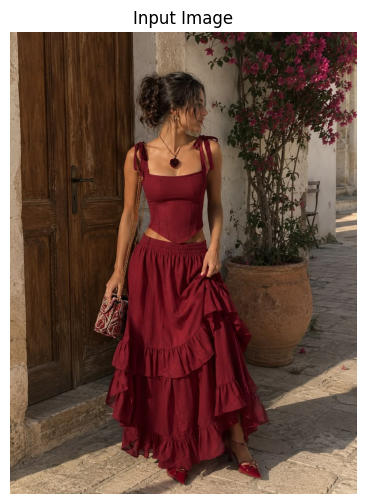

AFTER TRAINING MODEL PREDICTION

Predicted Style : Bohemian
Confidence      : 46.78%

All Class Probabilities:
------------------------------------------------------------
Bohemian             | ██████████████████                       46.78% ◀ TOP
Elegant Party        | ███████████                              28.76%
Casual Everyday      | ███                                      8.74%
Formal Office        | ███                                      7.89%
Sporty Athleisure    | ██                                       5.66%
Streetwear           |                                          2.16%


In [25]:
#image_url=  'https://i.pinimg.com/736x/5f/4d/34/5f4d3438928e88d0c17a1b0db5b4b271.jpg'
#image_url=  'https://i.pinimg.com/736x/f8/53/81/f85381b8963b6c7ebb1eb2178ef4ed22.jpg'
#image_url= 'https://i.pinimg.com/736x/5d/ff/a0/5dffa0ca31b0ed43e5e9e1bad3cfbe9b.jpg'
#image_url= 'https://i.pinimg.com/736x/9e/82/34/9e8234a404eff36869a701d7146fbaf6.jpg'
#image_url=  ' https://i.pinimg.com/736x/90/72/18/907218a2f5e07c8b6dc2bde056dbd4c0.jpg'
#image_url= 'https://i.pinimg.com/736x/ef/6b/32/ef6b3245fb9e83854a48a69188e61343.jpg'
#image_url= 'https://zapdress.com/cdn/shop/files/H_3JVE6UF3F49_0Z05Q1Y_S_23d4f01e-c1ea-43bd-99bb-1a85dd7f98dd.png?v=1772547049&width=1260'
#image_url= 'https://i.pinimg.com/736x/62/f3/37/62f337edcfa5f0d1e6e7e1225f70d9c6.jpg'
image_url= "https://i.pinimg.com/736x/94/6d/de/946dde33d34a38048cd9f9729883ac98.jpg"
image_url= 'https://i.pinimg.com/736x/97/29/e1/9729e1339eb4a3be34123fa18ec45e40.jpg'
image_url= 'https://i.pinimg.com/736x/31/9a/da/319adadbd2ab74e06edd16b12be58d23.jpg'
image_url= 'https://i.pinimg.com/control1/736x/81/d3/44/81d3440467cdbe04762922b2be93fa1c.jpg'
image_url= 'https://i.pinimg.com/736x/f6/29/80/f6298094dd7e66cbe39d245a7a347239.jpg'
image_url= 'https://i.pinimg.com/1200x/bb/14/ac/bb14acc5273ca5d4f94ee1cd804399bb.jpg'
image_url= 'https://i.pinimg.com/736x/04/2b/69/042b69e9c3ee6106ddb8e1c07ad4d5f1.jpg'
#image_url= 'https://i.pinimg.com/736x/22/36/55/223655eb71ba6683d1ce4692ff2596cf.jpg'
#image_url= 'https://i.pinimg.com/736x/a2/78/88/a27888974f7f59bc0ccb7c1a7f691ce3.jpg'
#image_url= 'https://i.pinimg.com/736x/1b/0f/9f/1b0f9f89e990119333b5b568991231bc.jpg'


# Define idx_to_style and class_names for the predict_after_training function
# STYLE_NAMES_USED is already defined in CELL 10 and contains the style names.
idx_to_style = {i: s for i, s in enumerate(STYLE_NAMES_USED)}
class_names = STYLE_NAMES_USED

predict_after_training(image_url)

## Part 2 — User Profile Builder & Segmentation
Everything above this line (Part 1) is the frozen style classifier — untouched.

This section:

Builds a per-user fashion profile from their images (reusing the trained model above, inference-only)
Fuses that profile with age + US city + gender
Clusters users into segments, with a full style-preference % breakdown per cohort
Adds cold-start cohort matching for users with no uploaded photos

In [26]:
# PART 2 — CELL 1 — Imports

from collections import defaultdict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import random

print('Part 2 imports ready.')

Part 2 imports ready.


In [27]:
# PART 2 — CELL 2 — Style Embedding Extractor (frozen, inference-only)
#
# Reuses the ALREADY-TRAINED `model` from Part 1 purely as a feature extractor —
# the 768-dim projected vision embedding, not the class logits. Never touches weights.

@torch.no_grad()
def get_style_embedding(pil_image):
    model.eval()
    inp = processor(images=pil_image, return_tensors='pt')['pixel_values'].to(device)
    vision_out = model.vision_model(pixel_values=inp)
    pooled     = vision_out.pooler_output
    projected  = model.visual_proj(pooled)
    return projected.squeeze(0).cpu().numpy()


_test_img = Image.new('RGB', (224, 224), color=(180, 180, 180))
_emb = get_style_embedding(_test_img)
print(f'✅ Embedding extractor working. Vector shape: {_emb.shape}')


✅ Embedding extractor working. Vector shape: (768,)


In [28]:
# PART 2 — CELL 3 — Demo User Panel (PLACEHOLDER — replace with real production data)
#
# No real user_id → images → age → city → gender table exists yet, so we simulate
# one from the existing test set to validate the pipeline end-to-end.
#
# REALISM: each synthetic user gets a "preferred style," with 75% of their photos
# drawn from it (25% other) — mimicking real style-consistent behaviour, not a random
# mix (a random mix would wash out each user's style signal — confirmed by testing).
# The sample pool is stratified by style so no class is under-represented by chance.
#
# TO GO TO PRODUCTION: replace this cell with your real tables:
#   user_images_df : columns [user_id, idx]
#   user_meta_df    : columns [user_id, age, city, gender]
# Everything from Stage B onward runs unchanged once those tables exist.

random.seed(42)
np.random.seed(42)

US_CITIES = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix',
             'San Francisco', 'Seattle', 'Miami', 'Boston', 'Atlanta',
             'Dallas', 'Denver']
GENDERS = ['Female', 'Male', 'Other']

n_sample = min(300, len(test_df))
per_class = max(1, n_sample // test_df['style'].nunique())
_parts = []
for _style, _group in test_df.groupby('style'):
    _parts.append(_group.sample(min(len(_group), per_class), random_state=42))
sample_pool = pd.concat(_parts).reset_index(drop=True)

n_users = max(20, len(sample_pool) // 5)
user_ids = [f'user_{i:03d}' for i in range(n_users)]
styles_available = sample_pool['style'].unique().tolist()
pool_by_style = {s: sample_pool[sample_pool['style'] == s].reset_index(drop=True)
                  for s in styles_available}

images_per_user = max(4, len(sample_pool) // n_users)
PREFERRED_RATIO = 0.75

records = []
for i, uid in enumerate(user_ids):
    pref = styles_available[i % len(styles_available)]
    n_pref  = max(1, round(images_per_user * PREFERRED_RATIO))
    n_other = images_per_user - n_pref

    pref_choices  = pool_by_style[pref].sample(n_pref, replace=True, random_state=i)
    other_pool    = sample_pool[sample_pool['style'] != pref]
    other_choices = other_pool.sample(n_other, replace=True, random_state=i + 1000)

    for _, row in pd.concat([pref_choices, other_choices]).iterrows():
        records.append({'user_id': uid, 'idx': row['idx'], 'style_label': row['style']})

user_images_df = pd.DataFrame(records)

user_meta_df = pd.DataFrame({
    'user_id': user_ids,
    'age':     np.random.randint(18, 60, size=len(user_ids)),
    'city':    np.random.choice(US_CITIES, size=len(user_ids)),
    'gender':  np.random.choice(GENDERS, size=len(user_ids), p=[0.48, 0.48, 0.04]),
})

print(f'Demo panel: {len(user_ids)} synthetic users, {len(user_images_df)} images')
print(user_images_df.groupby('user_id').size().describe()[['mean', 'min', 'max']])

Demo panel: 59 synthetic users, 295 images
mean    5.0
min     5.0
max     5.0
dtype: float64


In [30]:
# PART 2 — CELL 4 — Build User Profile Vectors (mean-pooled embeddings)

def build_user_profiles(user_images_df, raw_ds, batch_size=64):
    embeddings_by_user = defaultdict(list)
    idx_list = user_images_df['idx'].tolist()
    uid_list = user_images_df['user_id'].tolist()

    for start in tqdm(range(0, len(idx_list), batch_size)):
        for i, uid in zip(idx_list[start:start + batch_size], uid_list[start:start + batch_size]):
            img = raw_ds[int(i)]['image']
            if hasattr(img, 'convert'):
                img = img.convert('RGB')
            embeddings_by_user[uid].append(get_style_embedding(img))

    profiles = [
        {'user_id': uid, 'style_vector': np.mean(embs, axis=0), 'n_images': len(embs)}
        for uid, embs in embeddings_by_user.items()
    ]
    return pd.DataFrame(profiles)


user_profiles = build_user_profiles(user_images_df, raw_ds)
user_profiles = user_profiles.merge(user_meta_df, on='user_id', how='left')

print(f'Built profiles for {len(user_profiles)} users')
user_profiles[['user_id', 'n_images', 'age', 'city', 'gender']].head()

100%|██████████| 5/5 [00:24<00:00,  4.84s/it]

Built profiles for 59 users


,user_id,n_images,age,city,gender
0,user_000,5,56,Los Angeles,Male
1,user_001,5,46,Atlanta,Female
2,user_002,5,32,Denver,Other
3,user_003,5,25,Los Angeles,Male
4,user_004,5,38,Atlanta,Male


In [ ]:
# PART 2 — CELL 5 — Fuse Style + Age + City + Gender

def fuse_features(user_profiles_df, age_scaler=None, city_encoder=None, gender_encoder=None, fit=True):
    style_matrix = np.vstack(user_profiles_df['style_vector'].values)

    ages = user_profiles_df[['age']].values.astype(float)
    if fit or age_scaler is None:
        age_scaler = StandardScaler()
        age_scaled = age_scaler.fit_transform(ages)
    else:
        age_scaled = age_scaler.transform(ages)

    def _onehot(values, encoder):
        if fit or encoder is None:
            try:
                encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
            except TypeError:
                encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
            encoded = encoder.fit_transform(values)
        else:
            encoded = encoder.transform(values)
        return encoded, encoder

    city_encoded, city_encoder     = _onehot(user_profiles_df[['city']].values, city_encoder)
    gender_encoded, gender_encoder = _onehot(user_profiles_df[['gender']].values, gender_encoder)

    demographic_vector = np.hstack([age_scaled, city_encoded, gender_encoded])
    fused = np.hstack([style_matrix, demographic_vector])
    return fused, demographic_vector, age_scaler, city_encoder, gender_encoder


fused_features, demographic_features, age_scaler, city_encoder, gender_encoder = fuse_features(user_profiles)
n_style_dims  = user_profiles['style_vector'].iloc[0].shape[0]
n_city_dims   = len(city_encoder.categories_[0])
n_gender_dims = len(gender_encoder.categories_[0])

print(f'Fused feature matrix: {fused_features.shape}')
print(f'  → {n_style_dims} style dims + 1 age dim + {n_city_dims} city dims + {n_gender_dims} gender dims')

In [ ]:
# PART 2 — CELL 6 — Cluster Users (auto-selects number of clusters)


def cluster_users(fused_features, k_range=range(2, 9), random_state=42):
    best_k, best_score, best_model = None, -1, None
    scores = {}
    for k in k_range:
        if k >= len(fused_features):
            continue
        km = KMeans(n_clusters=k, random_state = random_state, n_init=10)
        labels = km.fit_predict(fused_features)
        score = silhouette_score(fused_features, labels)
        scores[k] = score
        if score > best_score:
            best_k, best_score, best_model = k, score, km

    print('Silhouette scores by k:')
    for k, s in scores.items():
        print(f'  k={k}: {s:.3f}' + ('  ← best' if k == best_k else ''))

    return best_model.predict(fused_features), best_model, best_k


cluster_labels, kmeans_model, best_k = cluster_users(fused_features)
user_profiles['cluster'] = cluster_labels

print(f'\n✅ Selected k={best_k} clusters')
print(user_profiles['cluster'].value_counts().sort_index())

In [ ]:
# PART 2 — CELL 7 — Cluster Profiles (full style-preference % breakdown per cohort)

merged = user_images_df.merge(user_profiles[['user_id', 'cluster']], on='user_id')
cluster_style_distribution = {}

print('=== Cluster Summary ===\n')
for c in sorted(user_profiles['cluster'].unique()):
    members = user_profiles[user_profiles['cluster'] == c]
    member_images = merged[merged['cluster'] == c]

    style_pct = (member_images['style_label'].value_counts(normalize=True) * 100).round(1)
    cluster_style_distribution[c] = style_pct.to_dict()

    top_city   = members['city'].value_counts().idxmax()
    top_gender = members['gender'].value_counts().idxmax()

    print(f'Cluster {c} | {len(members)} users | avg age {members["age"].mean():.1f} | '
          f'top city: {top_city} | top gender: {top_gender}')
    for style, pct in style_pct.sort_values(ascending=False).items():
        print(f'    {style:<20s} {pct:>5.1f}% of this cohort')
    print()

plt.figure(figsize=(8, 4))
user_profiles['cluster'].value_counts().sort_index().plot(kind='bar', color=plt.cm.Set2.colors)
plt.title('User Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

In [ ]:
# PART 2 — CELL 8 — Validation Checks

assert not np.isnan(fused_features).any(), 'NaNs found in fused features!'
assert user_profiles['cluster'].nunique() > 1, 'Only one cluster formed — check data variance'

size_ratio = user_profiles['cluster'].value_counts(normalize=True).max()
if size_ratio > 0.8:
    print(f' One cluster holds {size_ratio:.0%} of users — consider adjusting k or features')
else:
    print(f'Cluster sizes look reasonably balanced (largest = {size_ratio:.0%} of users)')


In [ ]:
# PART 2 — CELL 9 — Cold-Start Cohort Matching (for users with no photos)

cluster_demo_centroids = {
    c: demographic_features[user_profiles['cluster'].values == c].mean(axis=0)
    for c in sorted(user_profiles['cluster'].unique())
}

def match_user_to_cohort(age, city, gender, age_scaler, city_encoder, gender_encoder,
                          cluster_demo_centroids, cluster_style_distribution):
    age_scaled     = age_scaler.transform([[age]])
    city_encoded   = city_encoder.transform([[city]])
    gender_encoded = gender_encoder.transform([[gender]])
    demo_vector    = np.hstack([age_scaled, city_encoded, gender_encoded]).ravel()

    distances = {
        c: np.linalg.norm(demo_vector - centroid)
        for c, centroid in cluster_demo_centroids.items()
    }
    best_cluster = min(distances, key=distances.get)
    predicted_styles = cluster_style_distribution.get(best_cluster, {})
    return best_cluster, predicted_styles


example_cluster, example_prediction = match_user_to_cohort(
    age=27, city='Los Angeles', gender='Female',
    age_scaler=age_scaler, city_encoder=city_encoder, gender_encoder=gender_encoder,
    cluster_demo_centroids=cluster_demo_centroids,
    cluster_style_distribution=cluster_style_distribution,
)

print(f'No-photo user (age 27, Los Angeles, Female) → matched to Cluster {example_cluster}')
print('Predicted style preference (borrowed from that cohort):')
for style, pct in sorted(example_prediction.items(), key=lambda x: -x[1]):
    print(f'  {style:<20s} {pct:>5.1f}%')